In [1]:
using DifferentialEquations
using Plots
using SciMLOperators
using Rotations
using StaticArrays
using DoubleFloats
using LinearAlgebra
using GaussQuadrature
using LegendrePolynomials
using BenchmarkTools
using Profile
using ProfileVega
include("RotOperator.jl")

In [2]:
const numtype = Float64
const SV = SVector{3,numtype}
const neutrongyro::numtype = -1.83247172e4
const he3gyro::numtype = -2.037894585e4
const w::numtype = 6283.18530718
const B1::numtype = 4.0289106454828055e-1
const B0::numtype = 0.050

0.05

In [3]:
function order8CFET()
    s = 11
    f = zeros(numtype,s,4)
    f[1,1] = df64"0.169715531043933180094151"
    f[1,2] = df64"0.152866146944615909929839"
    f[1,3] = df64"0.119167378745981369601216"
    f[1,4] = df64"0.068619226448029559107538"
    f[2,1] = df64"0.379420807516005431504230"
    f[2,2] = df64"0.148839980923180990943008"
    f[2,3] = df64"-0.115880829186628075021088" 
    f[2,4] = df64"-0.188555246668412628269760"
    f[3,1] = df64"0.469459306644050573017994"
    f[3,2] = df64"-0.379844237839363505173921"
    f[3,3] = df64"0.022898814729462898505141"
    f[3,4] = df64"0.571855043580130805495594"
    f[4,1] = df64"-0.448225927391070886302766" 
    f[4,2] = df64"0.362889857410989942809900"
    f[4,3] = df64"-0.022565582830528472333301" 
    f[4,4] = df64"-0.544507517141613383517695"
    f[5,1] = df64"-0.293924473106317605373923"
    f[5,2] = df64"-0.026255628265819381983204"
    f[5,3] = df64"0.096761509131620390100068"
    f[5,4] = df64"0.000018330145571671744069"
    f[6,1] = df64"0.447109510586798614120629"
    f[6,3] = df64"-0.200762581179816221704073"
    for i=7:s
        for n=1:4
            f[i,n] = (-1)^(n+1) * f[12-i,n]
        end
    end
    f
end

# Pre-compute Gauss quandrature and Legendre polynomial evaluations
x_g, w_g = legendre(numtype, 5)
# Transform from interval (-1, 1) to interval (0, 1) 
const x_gauss = SVector{5, numtype}((x_g .+ 1) ./ 2)
const w_gauss = SVector{5, numtype}(w_g ./ 2)
const CFET_coefs = SMatrix{11,4}(order8CFET())
const Pls = SMatrix{5,4}(reshape([Pl(2*x_gauss[m]-1,n) for n=0:3 for m=1:5], (5,4)))

5×4 SMatrix{5, 4, Float64, 20} with indices SOneTo(5)×SOneTo(4):
 1.0  -0.90618       0.731743   -0.501031
 1.0  -0.538469     -0.0650762   0.417382
 1.0   2.22045e-16  -0.5        -3.33067e-16
 1.0   0.538469     -0.0650762  -0.417382
 1.0   0.90618       0.731743    0.501031

In [4]:
function gBfunc(t)
    #neutrongyro * B1 * cos(w * t), neutrongyro * B1 * sin(w * t), neutrongyro * B0
    neutrongyro * B1 * cos(w * t), 0.0, neutrongyro * B0
end

function dS(du, u, p, t)
    # Assigns du = dS/dt
    Bx, By, Bz = gBfunc(t)
    du[1] = u[2]*Bz - u[3]*By
    du[2] = u[3]*Bx - u[1]*Bz
    du[3] = u[1]*By - u[2]*Bx
end

function dS_static(u, p, t)
    # Uses static arrays instead
    Bx, By, Bz = gBfunc(t)
    du1 = u[2]*Bz - u[3]*By
    du2 = u[3]*Bx - u[1]*Bz
    du3 = u[1]*By - u[2]*Bx
    SA[du1,du2,du3]
end
function update_func(A,u,p,t)
    Bx, By, Bz = gBfunc(t)
    RotationVecGenerator{numtype}(-Bx, -By, -Bz)
end
u0::SV = @SVector [1.0; 0.0; 0.0]
tstart::numtype = 0.0
tend::numtype = 1e-1

0.1

In [5]:
function custom_perform_step!(L, t, dt, uprev, u, p)
    v1 = (1 / 2) * sqrt((3 + 2 * sqrt(numtype(6)/5)) / 7)
    v2 = (1 / 2) * sqrt((3 - 2 * sqrt(numtype(6)/5)) / 7)
    update_coefficients!(L, uprev, p, t - dt * v1 + dt / 2)
    A1 = L.A
    update_coefficients!(L, uprev, p, t + dt * v1 + dt / 2)
    A4 = L.A
    update_coefficients!(L, uprev, p, t - dt * v2 + dt / 2)
    A2 = L.A
    update_coefficients!(L, uprev, p, t + dt * v2 + dt / 2)
    A3 = L.A
    w1 = (1 / 2) - (numtype(1) / 6) * sqrt(numtype(5) / 6)
    w2 = (1 / 2) + (numtype(1) / 6) * sqrt(numtype(5) / 6)
    S1 = A1 + A4
    S2 = A2 + A3
    R1 = A4 - A1
    R2 = A3 - A2
    
    B0 = (1 / 2) * (w1 * S1 + w2 * S2)
    B2 = (1 / 2) * ((v1^2) * w1 * S1 + (v2^2) * w2 * S2)
    B1 = (1 / 2) * (v1 * w1 * R1 + v2 * w2 * R2)
    B3 = (1 / 2) * ((v1^3) * w1 * R1 + (v2^3) * w2 * R2)
    Q1 = (-38 * B0 / 5 + 24 * B2) * B3 - B3 * (-38 * B0 / 5 + 24 * B2)
    Q2 = (63 * B0 / 5 - 84 * B2) * (-5 * B1 / 28 + B3) -
         (-5 * B1 / 28 + B3) * (63 * B0 / 5 - 84 * B2)
    Q3 = (19 * B0 / 28 - 15 * B2 / 7) * (B0 * (B2 + dt * (61 * Q1 / 588 - Q2 / 12)) -
          (B2 + dt * (61 * Q1 / 588 - Q2 / 12)) * B0) -
         (B0 * (B2 + dt * (61 * Q1 / 588 - Q2 / 12)) -
          (B2 + dt * (61 * Q1 / 588 - Q2 / 12)) * B0) * (19 * B0 / 28 - 15 * B2 / 7)
    Q4 = B3 * (20 * Q1 / 7 + 10 * Q2) - (20 * Q1 / 7 + 10 * Q2) * B3
    Q5 = (-6025 * B0 / 4116 + 2875 * B2 / 343) * (B2 * Q1 - Q1 * B2) -
         (B2 * Q1 - Q1 * B2) * (-6025 * B0 / 4116 + 2875 * B2 / 343)
    Q6 = B3 * (20 * (Q3 + Q4) / 7 + 820 * dt * Q5 / 189) -
         (20 * (Q3 + Q4) / 7 + 820 * dt * Q5 / 189) * B3
    Q7 = (-numtype(1) / 42) * (B0 * (B0 * (Q3 - Q4 / 3 + dt * Q5) - (Q3 - Q4 / 3 + dt * Q5) * B0) -
          (B0 * (Q3 - Q4 / 3 + dt * Q5) - (Q3 - Q4 / 3 + dt * Q5) * B0) * B0)

    B1 = dt * B0
    B2 = (dt^2) * (Q1 + Q2)
    B3_4_5_6 = (dt^3) * (Q3 + Q4) + (dt^4) * (Q5 + Q6) + (dt^5) * Q7
    
    B = B1 + B2 + B3_4_5_6
    Bnorm = sqrt(B[1,2]^2 + B[1,3]^2 + B[2,3]^2)
    K = B./Bnorm
    u .= (Float64[1 0 0; 0 1 0; 0 0 1] + sin(Bnorm)*K + (1 - cos(Bnorm))*(K*K)) * uprev
end

function compute_quadrature!(t, dt, x_gauss, w_gauss, As, Pls)
    for m = 1:5
        Bx,By,Bz = gBfunc(x_gauss[m] * dt + t)
        for n = 1:4
            coef = w_gauss[m] * (2*n-1) * dt * Pls[m,n]
            As[1,n] += coef * Bx
            As[2,n] += coef * By
            As[3,n] += coef * Bz
        end
    end
end

function apply_exponentials!(u,f,As)
    for i = 11:-1:1
        A = As * view(f,i,:)
        Bnorm = norm(A)
        s, c = sincos(Bnorm)
        u .= u .* c .+ (cross(u, A) .* (s/Bnorm)) .+ A .* (dot(A, u) * (1 - c)/(Bnorm^2))
    end
end

function CFET_fast_step!(t,dt,uprev,u,p,f,x_gauss,w_gauss,As,Pls)
    compute_quadrature!(t, dt, x_gauss, w_gauss, As, Pls)
    apply_exponentials!(u,f,As)
end

CFET_fast_step! (generic function with 1 method)

In [6]:
function magnus_custom(dt)
    # A re-implemntation of Julia's order-8 Magnus integrator (MagnusGL8 from the DifferentialEquations.jl package)
    # I use a custom operator in order to override the default matrix exponential behavior.
    # This corresponds to the algorithm from https://link.springer.com/article/10.1023/A:1022311628317
    u = MVector{3}(u0)
    p = nothing
    rop = RotOperator(RotationVecGenerator{numtype}(0.0,0.0,0.0), update_func=update_func)
    t = numtype(0.0)
    while t + dt < tend
        custom_perform_step!(rop, t, dt, u, u, p)
        t += dt
    end
    custom_perform_step!(rop, t, (tend-t), u, u, p)
    u
end

function magnus_CFET_fast(dt::numtype)
    # A pretty fast implementation of the 8-th order scheme from https://arxiv.org/pdf/1102.5071.pdf
    # The two main optimizations made here are:
    # 1. Use static arrays
    # 2. Remove unnecessary allocations (by making global variables const)
    u = MVector{3}(u0)
    As = @MMatrix zeros(numtype,3,4)
    p = nothing
    t = numtype(0.0)
    f = CFET_coefs
    while t + dt < tend
        CFET_fast_step!(t, dt, u, u, p, f, x_gauss, w_gauss, As, Pls)
        t += dt
        As .= 0.0
    end
    CFET_fast_step!(t, (tend-t), u, u, p, f, x_gauss, w_gauss, As, Pls)
    u
end

function tsit(dt)
    # Tsitouras Runge Kutta scheme
    prob = ODEProblem(dS_static, u0, (tstart, tend))
    sol = solve(prob, tsit5(), dt=dt, adaptive=false, saveat=tend)
    uend = sol.u[end]
    uend
end

function dop(dt)
    # Standard DOP853 method from DifferentialEquations.jl
    # I use static arrays as well for this
    # I also enforce fixed step-size, to make performance comparisons easier
    u = SVector{3}(u0)
    prob = ODEProblem(dS_static, u, (tstart, tend))
    sol = solve(prob, DP8(), dt=dt, adaptive=false, saveat=tend)
    uend = sol.u[end]
    uend
end

function vern(dt)
    # High order Verner RK scheme
    prob = ODEProblem(dS_static, u0, (tstart, tend))
    sol = solve(prob, Vern9(), dt=dt, adaptive=false, saveat=tend)
    uend = sol.u[end]
    uend
end

function exact()
    # Exact solution for rotating-wave case
    # Solution is R^T U where R takes you to the rotating frame, and U is the exponential in the rotating frame
    R = RotationVec{numtype}(0,0,-w*tend)
    U = RotationVec{numtype}(-neutrongyro*B1*tend,0,-(neutrongyro*B0+w)*tend)
    transpose(R) * U * u0
end

exact (generic function with 1 method)

In [12]:
@btime magnus_CFET_fast(1e-5)

  2.889 ms (2 allocations: 144 bytes)


3-element MVector{3, Float64} with indices SOneTo(3):
  0.8245564642106754
 -0.5651744173376075
 -0.02616324359712377

In [13]:
@btime magnus_custom(1e-5)

  5.479 ms (20004 allocations: 1.98 MiB)


3-element MVector{3, Float64} with indices SOneTo(3):
  0.8245564642106292
 -0.5651744173376179
 -0.026163243597126615

In [14]:
@btime dop(1e-5)

  3.948 ms (132 allocations: 12.53 KiB)


3-element SVector{3, Float64} with indices SOneTo(3):
  0.8245564642106149
 -0.5651744173375544
 -0.026163243597210006

In [10]:
# "Exact" Solution
reference_sol= vern(numtype(1e-6))
dts = (numtype(10.0) .^ [-3.5, -4, -4.5, -5])
magnus_err = [norm(magnus_CFET_fast(dt)-reference_sol) for dt=dts]
single_exp_err = [norm(magnus_custom(dt)-reference_sol) for dt=dts]
dop_err = [norm(dop(dt)-reference_sol) for dt=dts]
vern_err = [norm(vern(dt)-reference_sol) for dt=dts]

4-element Vector{Float64}:
 0.016912887614295744
 1.8536881614386575e-6
 1.7991471210407467e-11
 6.793047903352195e-12

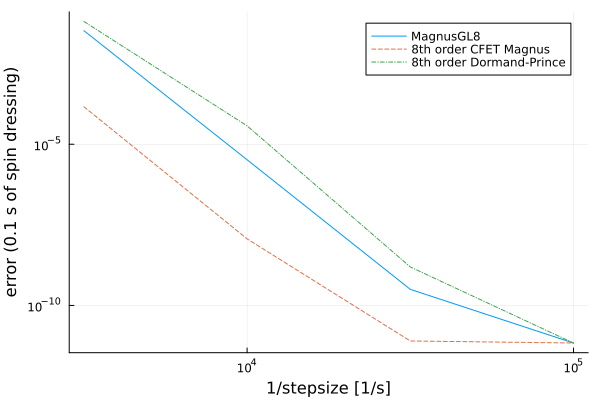

In [11]:
plot()
plot!(1 ./dts, single_exp_err, label="MagnusGL8")
plot!(1 ./dts, magnus_err, label="8th order CFET Magnus",linestyle=:dash)
plot!(1 ./dts, dop_err, label="8th order Dormand-Prince",linestyle=:dashdot)
#plot!(1 ./dts, vern_err, label="9th (10th?) order Verner",linestyle=:dot)
plot!(yaxis=:log, xaxis=:log, xlabel="1/stepsize [1/s]", ylabel="error (0.1 s of spin dressing)")
savefig("Comparison_Order_8.png")
plot!()